| Technological Institute of the Philippines | Quezon City - Computer Engineering |
|-------------------------------------------|------------------------------------|
| **Course Code:** | CPE 018 |
| **Code Title:** | Emerging Technologies in CpE 1 - Fundamentals of Computer Vision |
| **1st Semester** | AY 2025-2026 |
| **ACTIVITY NO. 6** | **Detecting Faces using OpenCV** |
| **Name:** | Pascual, Ken Leonard |
| **Section:** | CPE31S3 |
| **Date Performed:** | 8 October 2025 |
| **Date Submitted:** | 8 October 2025 |
| **Instructor:** | Engr. Verlyn V. Nojor |


## 1. Objectives

This activity aims to allow students to perform face detection on still images and videos using Haar cascades.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Utilize OpenCV to detect faces in still images and videos.
* Demonstrate the use of Haar-like features for detection of other human features.

## 3. Procedures and Outputs

Contrary to initial assumptions, conducting face detection on a static image and a video stream shares a remarkable similarity. Essentially, the latter is merely a sequential rendition of the former: when detecting faces in videos, it essentially involves applying face detection to every individual frame obtained from the camera feed. Of course, video face detection introduces additional elements like tracking, which aren't relevant to static images. Nevertheless, it's valuable to recognize that the fundamental principles behind both processes remain consistent.

### Performing face detection on still image

The first and most basic way to perform face detection is to load an image and detect faces in it. To make the result visually meaningful, we will draw rectangles around faces on the original image.

**Before implementing the code below**, check the contents of the `cv2.CascadeClassifier()` function. Provide an explanation of the function, its parameters before running the code below.

[HaarCascade xml files](https://github.com/opencv/opencv/tree/master/data/haarcascades)<br>
[Breaking Bad photo](https://www.peakpx.com/en/hd-wallpaper-desktop-prpln)

In [2]:
# Make sure that for this activity, you have downloaded the
# file indicated below from the resource linked in the instructional materials
# in the module.

import cv2
import matplotlib.pyplot as plt
picPath = 'breaking_bad.png'
haarPath = 'opencv-master/data/haarcascades_cuda/haarcascade_frontalface_default.xml'

def faceDetect(picPath):
    face_cascade = cv2.CascadeClassifier(haarPath)
    img = cv2.imread(picPath)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 3)
    
    for (x, y, w, h) in faces:
      img = cv2.rectangle(img, (x, y), (x+w, y+h), (255,0,0), 2)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

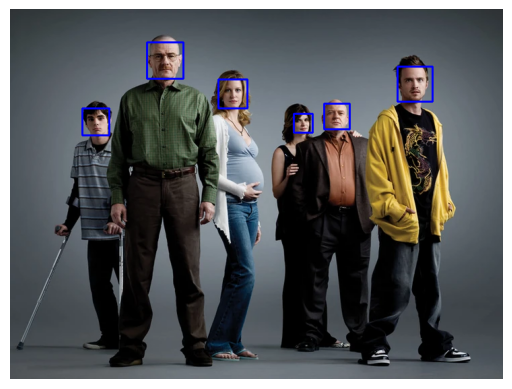

In [3]:
faceDetect(picPath)

**Analysis**:

- Based on your earlier analysis, where do you think the face detection works in the line of code above?


In [5]:
def faceDetect(picPath):
  face_cascade = cv2.CascadeClassifier(haarPath)

  img = cv2.imread(picPath)
  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  faces = face_cascade.detectMultiScale(gray, 1.3, 5) #it detects faces here

  for (x, y, w, h) in faces:
    img = cv2.rectangle(img, (x, y), (x+w, y+h), (255,0,0), 2)


- Provide an analysis of the parameters of the `detectMultiScale` method.


In the *detectMultiScale* method, it has three parameters:
* gray means that the input image is stored in grayscale
* 1.3 is the *scaleFactor*, which changes how much the image size is reduced at each image scale. The smaller the value, the slower it runs, but the more faces it can detect.
* 5 is the *minNeighbors*, which determines how many rectangles around a region are required for a positive detection. Higher values mean a stricter detection, resulting in fewer false positives, but may miss faces.


- Change the color of the border of the detected faces to red.


In [7]:
# Make sure that for this activity, you have downloaded the
# file indicated below from the resource linked in the instructional materials
# in the module.

import cv2
import matplotlib.pyplot as plt
picPath = 'breaking_bad.png'
haarPath = 'opencv-master/data/haarcascades_cuda/haarcascade_frontalface_default.xml'

def faceDetect(picPath):
    face_cascade = cv2.CascadeClassifier(haarPath)
    img = cv2.imread(picPath)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 3)
    
    for (x, y, w, h) in faces:
      img = cv2.rectangle(img, (x, y), (x+w, y+h), (0,0,255), 2) 
    #it's in BGR, so set R to 255, and B to 0

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

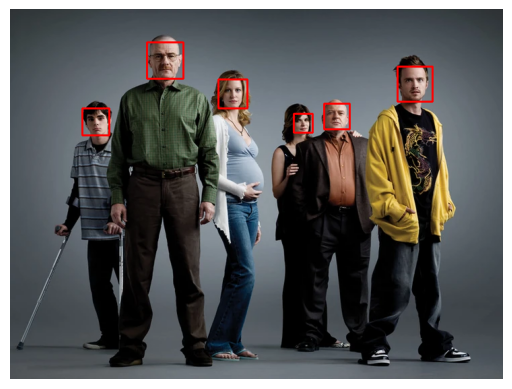

In [8]:
faceDetect(picPath)

- Are you able to make the borders thicker? Demonstrate.

The borders can be made thicker by adjusting the thickness in this line:

In [ ]:
      img = cv2.rectangle(img, (x, y), (x+w, y+h), (0,0,255), 2 #this one) 

In [12]:
# Make sure that for this activity, you have downloaded the
# file indicated below from the resource linked in the instructional materials
# in the module.

import cv2
import matplotlib.pyplot as plt
picPath = 'breaking_bad.png'
haarPath = 'opencv-master/data/haarcascades_cuda/haarcascade_frontalface_default.xml'

def faceDetect(picPath):
    face_cascade = cv2.CascadeClassifier(haarPath)
    img = cv2.imread(picPath)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 3)
    
    for (x, y, w, h) in faces:
      img = cv2.rectangle(img, (x, y), (x+w, y+h), (0,0,255), 4) 
    #it's in BGR, so set R to 255, and B to 0

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

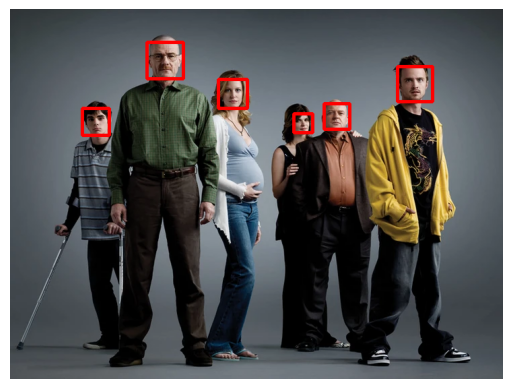

In [13]:
faceDetect(picPath)

### Performing face detection on video

**Step 1**: Create a file called face_detection.py and include the following codes.

In [14]:
import cv2

**Step 2:** After this, we declare a method, `detect()`, which will perform face detection.

In [16]:
def detect():
  face_cascade = cv2.CascadeClassifier('/content/haarcascade_frontalface_default.xml')
  eye_cascade = cv2.CascadeClassifier('/content/haarcascade_eye.xml')
  camera = cv2.VideoCapture(0)

**Step 3:** The first thing we need to do inside the detect() method is to load the Haar cascade files so that OpenCV can operate face detection. As we copied
the cascade files in the local `cascades/` folder, we can use a relative path. Then, we open a VideoCapture object (the camera feed). The VideoCapture  constructor takes a parameter, which indicates the camera to be used; zero indicates the first camera available.

In [ ]:
  while (True):
    ret, frame = camera.read()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

**Step 4:** Next up, we capture a frame. The read() method returns two values: a Boolean indicating the success of the frame read operation, and the frame
itself. We capture the frame, and then we convert it to grayscale. This is a necessary operation, because face detection in OpenCV happens in the grayscale color space:

In [ ]:
faces = face_cascade.detectMultiScale(gray, 1.3, 5)

**Step 5:** Much like the single still image example, we call detectMultiScale on the grayscale version of the frame.

In [ ]:
  for (x,y,w,h) in faces:
    img = cv2.rectangle(frame,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray = gray[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray, 1.03,
    5, 0, (40,40))

**Step 6:** Here we have a further step compared to the still image example: we create a region of interest corresponding to the face rectangle, and within this rectangle, we operate "eye detection". This makes sense as you wouldn't want to go looking for eyes outside a face (well, for human beings at least!).

In [ ]:
  for (ex,ey,ew,eh) in eyes:
    cv2.rectangle(img,(ex,ey),(ex+ew,ey+eh),
    (0,255,0),2)

**Step 7:** Again, we loop through the resulting eye tuples and draw green rectangles around them.

In [ ]:

    cv2.imshow("camera", frame)
    if cv2.waitKey(1000 / 12) & 0xff == ord("q"):
      break

  camera.release()
  cv2.destroyAllWindows()

if __name__ == "__main__":
detect()

**Provide the following**:

- Screenshot of the output for the working code once you've put it all together.

### Code

In [19]:
import cv2

def detect():
    face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
    eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')

    if face_cascade.empty() or eye_cascade.empty():
        print("Cascade files not loaded — check your paths.")
        return

    camera = cv2.VideoCapture(0)

    while True:
        ret, frame = camera.read()
        if not ret:
            print("Camera not detected.")
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        faces = face_cascade.detectMultiScale(gray, 1.3, 5)
        for (x, y, w, h) in faces:
            cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)
            roi_gray = gray[y:y + h, x:x + w]
            roi_color = frame[y:y + h, x:x + w]

            eyes = eye_cascade.detectMultiScale(roi_gray, 1.03, 5, 0, (40, 40))
            for (ex, ey, ew, eh) in eyes:
                cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 2)

        cv2.imshow("camera", frame)

        if cv2.waitKey(int(1000 / 12)) & 0xFF == ord('q'):
            break

    camera.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    detect()

### Output

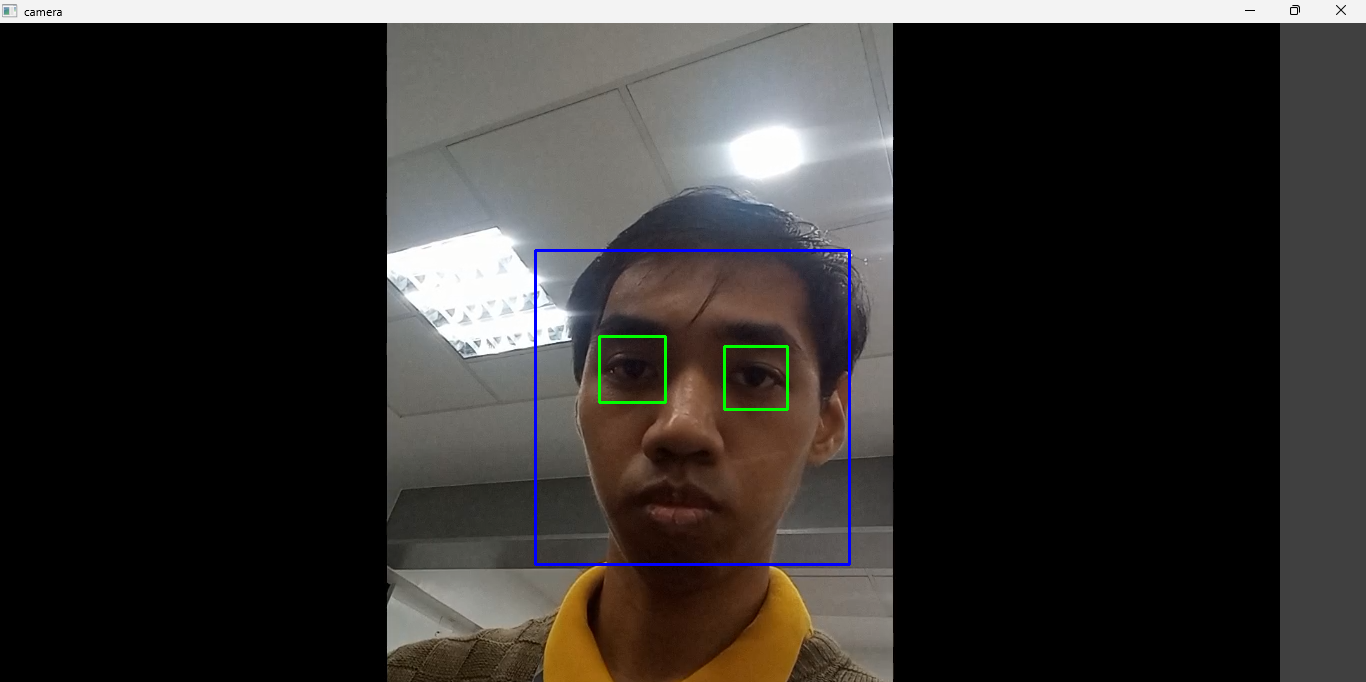

- Summary of the steps you've performed along with observations.

*First, I imported the library needed as well as the Haar cascade classifiers. Then, afterwards, a prompt to open the camera was created, looping it to continuously read and process frames. Afterwards, these frames are preprocessed to be grayscale. Then, the algorithm to detect faces and eyes were implemented, as well as instructions to draw rectangles around those. The result is then displayed through the camera feed.*
<br>

*This results in a camera feed similar to the output above, as the camera detects faces and eyes in real time. However, it was observed that differences in lighting and angle of the face affect its accuracy in detecting faces.*



## 4. Supplementary Activity

In your Cameo project, include real-time face detection using Haar cascade. Show screenshots of the working demonstration for this supplementary activity.

Additionally, implement similar steps to detect a smile using Haar cascades.

### Real-time face detection using Haar cascade

In [14]:
import cv2

def full_face_detect():
    face_cascade = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")
    eye_cascade = cv2.CascadeClassifier("haarcascade_eye.xml")
    smile_cascade = cv2.CascadeClassifier("haarcascade_smile.xml") # added smile cascade detector


    # Check if the cascade files are loaded properly
    if face_cascade.empty() or eye_cascade.empty() or smile_cascade.empty():
        raise IOError("Failed to load.")

    # error handling for camera
    camera = cv2.VideoCapture(0)
    if not camera.isOpened():
        raise IOError("Unable to open webcam.")

    # open camera and start detecting faces, eyes, and smiles
    while True:
        ret, frame = camera.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.3, 5)

        for (x, y, w, h) in faces:
            cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
            roi_gray = gray[y:y+h, x:x+w]
            roi_color = frame[y:y+h, x:x+w]

            eyes = eye_cascade.detectMultiScale(roi_gray, 1.03, 5, 0, (40, 40))
            for (ex, ey, ew, eh) in eyes:
                cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)

            smiles = smile_cascade.detectMultiScale(roi_gray, 1.7, 22)
            for (sx, sy, sw, sh) in smiles:
                cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 0, 255), 2)

        cv2.imshow("camera", frame)
        if cv2.waitKey(int(1000 / 12)) & 0xff == ord("q"):
            camera.release()
            cv2.destroyAllWindows()
            break
        
full_face_detect()

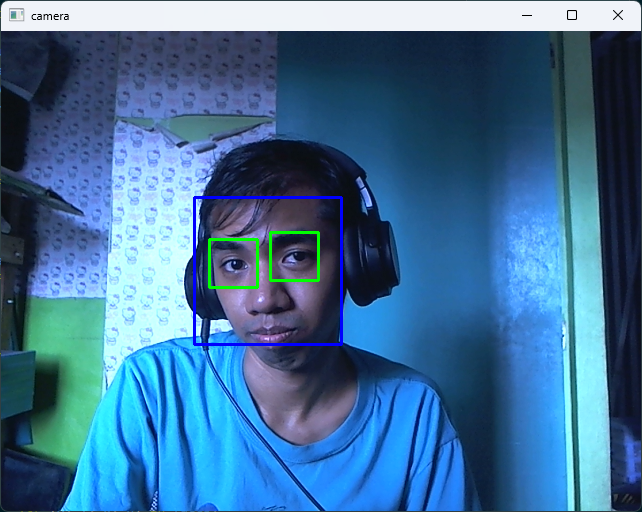

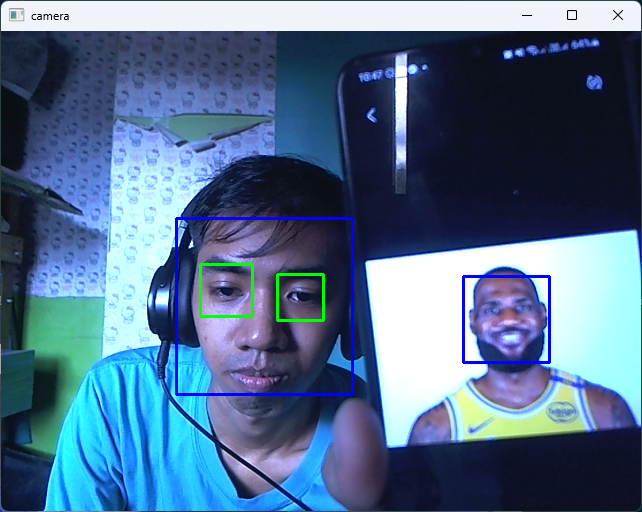

### Smile detection using Haar cascade

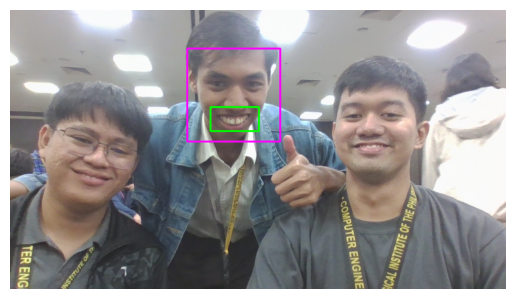

In [ ]:
#for images
import cv2
import matplotlib.pyplot as plt

picPath = 'sample5.jpg'
face_cascade = cv2.CascadeClassifier('opencv-master/data/haarcascades_cuda/haarcascade_frontalface_default.xml')
smile_cascade = cv2.CascadeClassifier('opencv-master/data/haarcascades_cuda/haarcascade_smile.xml')

img = cv2.imread(picPath)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=9)

for (x, y, w, h) in faces:
    # Draw rectangle around the face
    cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 255), 3)

    # Region of Interest (ROI) for smile detection
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]

    # Detect smiles inside face
    smiles = smile_cascade.detectMultiScale(roi_gray, scaleFactor=1.1, minNeighbors=15)

    for (sx, sy, sw, sh) in smiles:
        cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 255, 0), 4)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


In [15]:
#for realtime video from camera
import cv2

def full_face_detect():
    face_cascade = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")
    eye_cascade = cv2.CascadeClassifier("haarcascade_eye.xml")
    smile_cascade = cv2.CascadeClassifier("haarcascade_smile.xml") # added smile cascade detector


    # Check if the cascade files are loaded properly
    if face_cascade.empty() or eye_cascade.empty() or smile_cascade.empty():
        raise IOError("Failed to load.")

    # error handling for camera
    camera = cv2.VideoCapture(0)
    if not camera.isOpened():
        raise IOError("Unable to open webcam.")

    # open camera and start detecting faces, eyes, and smiles
    while True:
        ret, frame = camera.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.3, 5)

        for (x, y, w, h) in faces:
            cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
            roi_gray = gray[y:y+h, x:x+w]
            roi_color = frame[y:y+h, x:x+w]

            eyes = eye_cascade.detectMultiScale(roi_gray, 1.03, 5, 0, (40, 40))
            for (ex, ey, ew, eh) in eyes:
                cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)

            smiles = smile_cascade.detectMultiScale(roi_gray, 1.7, 22)
            for (sx, sy, sw, sh) in smiles:
                cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 0, 255), 2)

        cv2.imshow("camera", frame)
        if cv2.waitKey(int(1000 / 12)) & 0xff == ord("q"):
            camera.release()
            cv2.destroyAllWindows()
            break
        
full_face_detect()

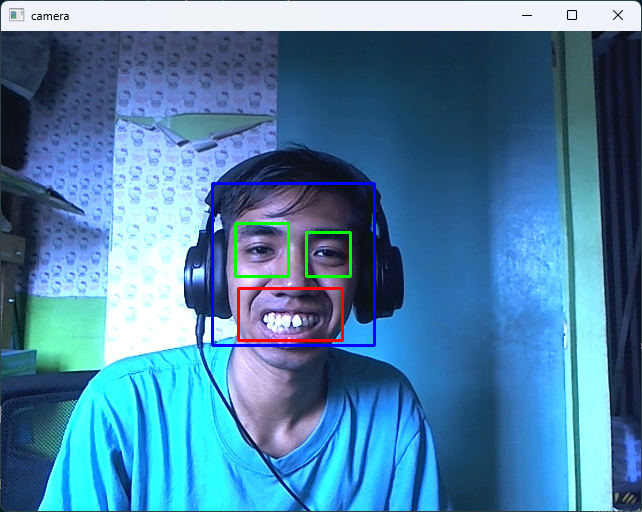

## 5. Summary, Conclusions and Lessons Learned

*In this activity, I was able to utilize OpenCV to learn about face detection, as well as the different parameters, functions, and classifiers to make it possible. I was able to understand how the detectMultiScale method affects how the face detection algorithm works, which is by scaling the image and finding "rectangle" neighbors for detection.* <br>

*Furthermore, I was able to accomplish the tasks given to detect faces both in images as well as videos captured in real time.*

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*